# Exploratory Data Analysis

### Disconnected data:
In the fully joined data set, 51279 articles are connected to transaction, 458235 customers are connected to transaction
Half the articles and customers are orphaned. Do we want to drop them or fill with the full data set?

### Articles:
Create indicator features for each individual label:

- product_code
- product_type_no
- graphical_appearance_no
- colour_group_code
- perceived_colour_value_id
- perceived_colour_master_id
- department_no
- index_group_no
- section_no
- garment_group_no

Handle "Unknown" and -1 values

## Join pre-processed data

In [20]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
data_path = Path("../data") / 'processed'

articles = pd.read_csv(data_path/"articles_hm_cleaned.csv")
customers = pd.read_csv(data_path/"customer_hm_cleaned.csv")
transactions = pd.read_csv(data_path/"transactions_hm_cleaned.csv")

/user/projects/mids_207_project/src
../data/processed


# Articles

In [10]:
articles.head()

,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."


In [24]:
articles.describe()

,article_id,product_code,product_type_no,graphical_appearance_no,colour_group_code,perceived_colour_value_id,perceived_colour_master_id,department_no,index_group_no,section_no,garment_group_no
count,1.055420e+05,105542.000000,105542.000000,1.055420e+05,105542.000000,105542.000000,105542.000000,105542.000000,105542.000000,105542.000000,105542.000000
mean,6.984246e+08,698424.563378,234.861875,1.009515e+06,32.233822,3.206183,7.807972,4532.777833,3.171534,42.664219,1010.438290
std,1.284624e+08,128462.384432,75.049308,2.241359e+04,28.086154,1.563839,5.376727,2712.692011,4.353234,23.260105,6.731023
min,1.087750e+08,108775.000000,-1.000000,-1.000000e+00,-1.000000,-1.000000,-1.000000,1201.000000,1.000000,2.000000,1001.000000
25%,6.169925e+08,616992.500000,252.000000,1.010008e+06,9.000000,2.000000,4.000000,1676.000000,1.000000,20.000000,1005.000000
50%,7.022130e+08,702213.000000,259.000000,1.010016e+06,14.000000,4.000000,5.000000,4222.000000,2.000000,46.000000,1009.000000
75%,7.967030e+08,796703.000000,272.000000,1.010016e+06,52.000000,4.000000,11.000000,7389.000000,4.000000,61.000000,1017.000000
max,9.594610e+08,959461.000000,762.000000,1.010029e+06,93.000000,7.000000,20.000000,9989.000000,26.000000,97.000000,1025.000000


In [32]:
print(f"{len(articles['product_code'].unique())=}")
print(f"{len(articles['product_type_no'].unique())=}")
print(f"{len(articles['graphical_appearance_no'].unique())=}")
print(f"{len(articles['colour_group_code'].unique())=}")
print(f"{len(articles['perceived_colour_value_id'].unique())=}")
print(f"{len(articles['perceived_colour_master_id'].unique())=}")
print(f"{len(articles['department_no'].unique())=}")
print(f"{len(articles['index_group_no'].unique())=}")
print(f"{len(articles['garment_group_no'].unique())=}")

len(articles['product_code'].unique())=47224
len(articles['product_type_no'].unique())=132
len(articles['graphical_appearance_no'].unique())=30
len(articles['colour_group_code'].unique())=50
len(articles['perceived_colour_value_id'].unique())=8
len(articles['perceived_colour_master_id'].unique())=20
len(articles['department_no'].unique())=299
len(articles['index_group_no'].unique())=5
len(articles['garment_group_no'].unique())=21


In [43]:
# for col in articles.columns:
#     print(f"{len(articles[col] == -1)}")
articles[articles['perceived_colour_value_id'] == -1]

,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
21238,592986010,592986,Cool tiebelt dressed,272,Trousers,Garment Lower body,-1,Unknown,-1,Unknown,...,Trouser,A,Ladieswear,1,Ladieswear,11,Womens Tailoring,1009,Trousers,"Wide, high-waisted trousers in woven fabric wi..."
39690,662344003,662344,Lily blouse,258,Blouse,Garment Upper body,-1,Unknown,-1,Unknown,...,Blouse,A,Ladieswear,1,Ladieswear,11,Womens Tailoring,1010,Blouses,Long-sleeved blouse in satin with a small stan...
40806,665665001,665665,J LORENZO TRS EQ,272,Trousers,Garment Lower body,-1,Unknown,-1,Unknown,...,Equatorial Assortment,A,Ladieswear,1,Ladieswear,15,Womens Everyday Collection,1001,Unknown,Leggings in soft jersey made from a viscose bl...
49595,694968001,694968,Sagus Jogger,272,Trousers,Garment Lower body,-1,Unknown,-1,Unknown,...,Jersey Fancy,F,Menswear,3,Menswear,55,Contemporary Street,1005,Jersey Fancy,Joggers in sweatshirt fabric with an elasticat...
49597,694968004,694968,Sagus Jogger,272,Trousers,Garment Lower body,-1,Unknown,-1,Unknown,...,Jersey Fancy,F,Menswear,3,Menswear,55,Contemporary Street,1005,Jersey Fancy,Joggers in sweatshirt fabric with an elasticat...
50122,696114001,696114,W MARS TRS CNY,272,Trousers,Garment Lower body,-1,Unknown,-1,Unknown,...,Asia Assortment,A,Ladieswear,1,Ladieswear,15,Womens Everyday Collection,1001,Unknown,Ankle-length trousers in woven fabric with ela...
50123,696114002,696114,W MARS TRS CNY,272,Trousers,Garment Lower body,-1,Unknown,-1,Unknown,...,Asia Assortment,A,Ladieswear,1,Ladieswear,15,Womens Everyday Collection,1001,Unknown,Ankle-length trousers in woven fabric with ela...
50129,696124001,696124,W PASTILLE DRESS CNY,265,Dress,Garment Full body,-1,Unknown,-1,Unknown,...,Asia Assortment,A,Ladieswear,1,Ladieswear,15,Womens Everyday Collection,1001,Unknown,Calf-length dress in woven fabric with a round...
50130,696124002,696124,W PASTILLE DRESS CNY,265,Dress,Garment Full body,-1,Unknown,-1,Unknown,...,Asia Assortment,A,Ladieswear,1,Ladieswear,15,Womens Everyday Collection,1001,Unknown,Calf-length dress in woven fabric with a round...
50289,696500001,696500,J MADRID CNY,252,Sweater,Garment Upper body,-1,Unknown,-1,Unknown,...,Asia Assortment,A,Ladieswear,1,Ladieswear,15,Womens Everyday Collection,1001,Unknown,Sweatshirt in sturdy jersey made from a cotton...


# Customers

In [11]:
customers.head()

,customer_id,FN,Active,club_member_status,fashion_news_frequency,age
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0,0,ACTIVE,NONE,49
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,0,0,ACTIVE,NONE,25
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,0,0,ACTIVE,NONE,24
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,0,0,ACTIVE,NONE,54
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1,1,ACTIVE,REGULARLY,52


In [29]:
len(customers["customer_id"].unique())

1048575

In [15]:
customers["FN"].unique()

array([0, 1])

In [16]:
customers["Active"].unique()

array([0, 1])

In [17]:
customers["club_member_status"].unique()

array(['ACTIVE', 'PRE-CREATE', 'LEFT CLUB'], dtype=object)

In [18]:
customers["fashion_news_frequency"].unique()

array(['NONE', 'REGULARLY', 'MONTHLY'], dtype=object)

In [30]:
customers[customers['age'] == 99]

,customer_id,FN,Active,club_member_status,fashion_news_frequency,age
186870,23b7e974d88a6373ba0e02fd39b1a048dec0ac8a9b4ed0...,0,0,ACTIVE,NONE,99
226365,2b5284f19d272d7b7f1006289566076d72a7f097feb03f...,0,0,ACTIVE,NONE,99
286274,36d219eb822d04d07e5bb31e39caffefc17da81ff4a19b...,0,0,ACTIVE,NONE,99
299817,39719241efb3559eca60886d58f0fe01cbf8d5efea0e25...,1,1,ACTIVE,REGULARLY,99
308676,3b28156770e0a17436b29831e41394528f74b4ec2c37d3...,0,0,ACTIVE,NONE,99
311081,3b9ec1854ba779c3c11389985299e642b5779947ff8395...,1,1,ACTIVE,REGULARLY,99
546159,687c675e64e5f5d962c99ebf915da230be8c907a65a1d5...,0,0,PRE-CREATE,NONE,99
613464,7558adbc0401acdd74a7c8633ad97d25979e9859b8abca...,0,0,ACTIVE,NONE,99
836730,a01bd2e0e8bbf8db61f0e623a05325cde84955a37415b7...,1,1,ACTIVE,REGULARLY,99
839909,a0b9e2473f699821b72833824a3e95972862039a49c5e9...,0,0,PRE-CREATE,NONE,99


# Transactions

In [12]:
transactions.head()

,t_dat,customer_id,article_id,price,sales_channel_id
0,2019-11-05,3e2b60b679e62fb49516105b975560082922011dd752ec...,698328010,0.016932,2
1,2019-05-22,89647ac2274f54c770aaa4b326e0eea09610c252381f37...,760597002,0.033881,2
2,2019-05-10,2ebe392150feb60ca89caa8eff6c08b7ef1138cd6fdc71...,488561032,0.016932,2
3,2019-08-26,7b3205de4ca17a339624eb5e3086698e9984eba6b47c56...,682771001,0.033881,2
4,2019-08-10,3b77905de8b32045f08cedb79200cdfa477e9562429a39...,742400033,0.003220,1


In [19]:
transactions["sales_channel_id"].unique()

array([2, 1])

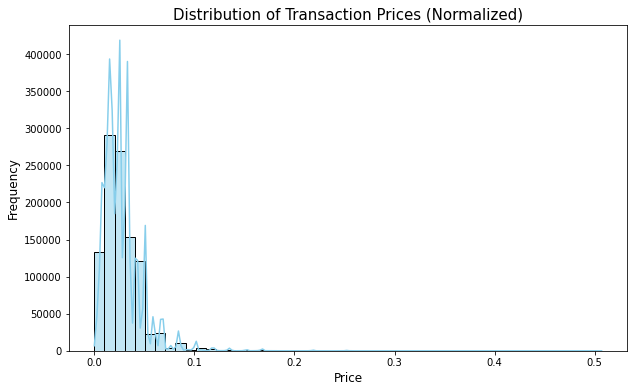

In [22]:
plt.figure(figsize=(10, 6))
sns.histplot(transactions['price'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Transaction Prices (Normalized)', fontsize=15)
plt.xlabel('Price', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

# Join

In [26]:
df = pd.merge(transactions, articles, how='left', on='article_id')
df = pd.merge(df, customers, how='left', on='customer_id')

In [27]:
df.describe()

,article_id,price,sales_channel_id,product_code,product_type_no,graphical_appearance_no,colour_group_code,perceived_colour_value_id,perceived_colour_master_id,department_no,index_group_no,section_no,garment_group_no,FN,Active,age
count,1.040101e+06,1.040101e+06,1.040101e+06,1.040101e+06,1.040101e+06,1.040101e+06,1.040101e+06,1.040101e+06,1.040101e+06,1.040101e+06,1.040101e+06,1.040101e+06,1.040101e+06,806367.000000,806367.000000,806367.000000
mean,6.747603e+08,2.778278e-02,1.693671e+00,6.747603e+05,2.457314e+02,1.009587e+06,2.645338e+01,3.303932e+00,7.655305e+00,2.832156e+03,2.356353e+00,3.660410e+01,1.010794e+03,0.433385,0.427231,36.364447
std,1.172480e+08,1.935509e-02,4.609682e-01,1.172480e+05,6.769572e+01,2.074583e+04,2.621410e+01,1.413313e+00,5.076155e+00,2.054930e+03,4.665324e+00,2.301846e+01,6.571729e+00,0.495543,0.494677,13.009324
min,1.087750e+08,2.372880e-04,1.000000e+00,1.087750e+05,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,1.201000e+03,1.000000e+00,2.000000e+00,1.001000e+03,0.000000,0.000000,16.000000
25%,6.293810e+08,1.523729e-02,1.000000e+00,6.293810e+05,2.530000e+02,1.010010e+06,9.000000e+00,2.000000e+00,5.000000e+00,1.610000e+03,1.000000e+00,1.500000e+01,1.005000e+03,0.000000,0.000000,26.000000
50%,7.059880e+08,2.540678e-02,2.000000e+00,7.059880e+05,2.640000e+02,1.010016e+06,1.000000e+01,4.000000e+00,5.000000e+00,1.717000e+03,1.000000e+00,4.700000e+01,1.010000e+03,0.000000,0.000000,32.000000
75%,7.501970e+08,3.388136e-02,2.000000e+00,7.501970e+05,2.730000e+02,1.010016e+06,4.300000e+01,4.000000e+00,1.100000e+01,3.937000e+03,2.000000e+00,6.000000e+01,1.017000e+03,1.000000,1.000000,48.000000
max,8.797400e+08,5.067797e-01,2.000000e+00,8.797400e+05,5.320000e+02,1.010028e+06,9.300000e+01,7.000000e+00,2.000000e+01,9.989000e+03,2.600000e+01,9.700000e+01,1.025000e+03,1.000000,1.000000,99.000000


In [37]:
# only using half the customer data
len(df['customer_id'].unique())

458235

In [38]:
# only using half the article data
len(df['article_id'].unique())

51279